# 🤖 EDA v3 — Walmart Sales Forecasting with Machine Learning
**Builds on EDA v2.** Reads the feature-engineered dataset from PostgreSQL/CSV.

### What this notebook does:
1. Loads feature-engineered data from EDA v2 (`walmart_features.csv`)
2. Performs a **time-based train/test split** (no data leakage)
3. Trains 3 models: **Ridge Regression, Random Forest, Gradient Boosting**
4. Evaluates with MAE, RMSE, MAPE, R²
5. Analyses **feature importance**
6. Generates an **8-week future sales forecast**

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.float_format', '{:,.4f}'.format)
print('All libraries loaded')

All libraries loaded


In [4]:
df = pd.read_csv("C:/Users/User/OneDrive/Desktop/Projects/walmart_features.csv", parse_dates=['Date'])
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range: {df.Date.min().date()} to {df.Date.max().date()}')
print(f'Stores: {df["Store"].nunique()}')
df.head(3)

Loaded: 6,435 rows x 31 columns
Date range: 2010-02-05 to 2012-10-26
Stores: 45


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,...,pct_change_1w,pct_change_4w,pre_holiday,post_holiday,is_november,is_december,is_q4,is_summer,quarter,store_tier
0,1,2010-02-05,"1,643,690.9000",0,42.3100,2.5720,211.0964,8.1060,2010,2,...,NaN,NaN,1,0,0,0,0,0,1,Top
1,1,2010-02-12,"1,641,957.4400",1,38.5100,2.5480,211.2422,8.1060,2010,2,...,-0.1055,NaN,0,0,0,0,0,0,1,Top
2,1,2010-02-19,"1,611,968.1700",0,39.9300,2.5140,211.2891,8.1060,2010,2,...,-1.8264,NaN,0,1,0,0,0,0,1,Top


## Time-Based Train / Test Split

Features used for ML:
 1. Store
 2. Holiday_Flag
 3. Temperature
 4. Fuel_Price
 5. CPI
 6. Unemployment
 7. year
 8. month
 9. week
10. month_name
11. week_type
12. week_of_year
13. lag_1
14. lag_2
15. lag_4
16. lag_52
17. rolling_4_mean
18. rolling_4_std
19. rolling_8_mean
20. pre_holiday
21. post_holiday
22. is_november
23. is_december
24. is_q4
25. is_summer
26. quarter

Train: 2011-02-04 to 2011-12-30 (2,160 rows)
Test : 2012-01-06 to 2012-10-26 (1,935 rows)


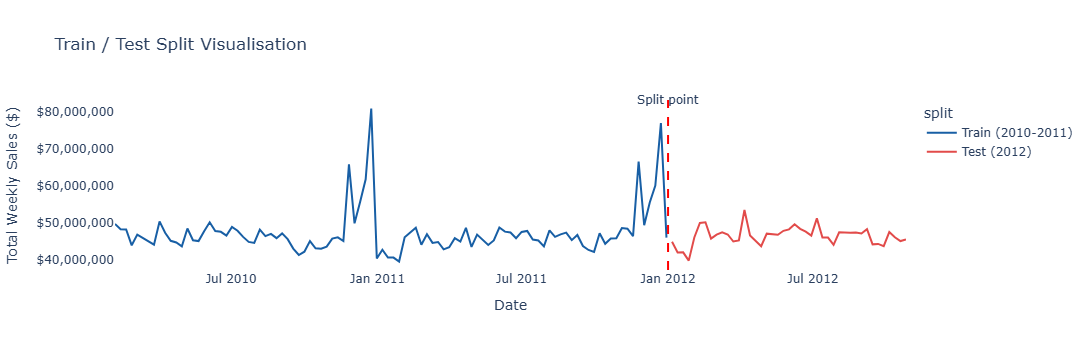

In [6]:
# Features: everything except target, date, and columns that cause issues
DROP_COLS = ['Weekly_Sales', 'Date', 'store_tier', 'pct_change_1w', 'pct_change_4w']
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

print("Features used for ML:")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"{i:2d}. {f}")

# Train/Test split
SPLIT_DATE = pd.Timestamp("2012-01-01")

train = df[df["Date"] < SPLIT_DATE].dropna(subset=FEATURE_COLS + ["Weekly_Sales"])
test  = df[df["Date"] >= SPLIT_DATE].dropna(subset=FEATURE_COLS + ["Weekly_Sales"])

X_train = train[FEATURE_COLS]
y_train = train["Weekly_Sales"]

X_test = test[FEATURE_COLS]
y_test = test["Weekly_Sales"]

print(f"\nTrain: {train['Date'].min().date()} to {train['Date'].max().date()} ({len(train):,} rows)")
print(f"Test : {test['Date'].min().date()} to {test['Date'].max().date()} ({len(test):,} rows)")

# Plot
sv = df.groupby("Date", as_index=False)["Weekly_Sales"].sum()

sv["split"] = sv["Date"].apply(
    lambda d: "Train (2010-2011)" if d < SPLIT_DATE else "Test (2012)"
)

fig = px.line(
    sv,
    x="Date",
    y="Weekly_Sales",
    color="split",
    color_discrete_map={
        "Train (2010-2011)": "#185FA5",
        "Test (2012)": "#E24B4A"
    },
    title="Train / Test Split Visualisation",
    labels={
        "Weekly_Sales": "Total Weekly Sales ($)",
        "Date": "Date"
    }
)

fig.update_layout(
    height=350,
    plot_bgcolor="white",
    yaxis=dict(tickformat="$,.0f")
)

# Draw split line (compatible with newer pandas versions)
fig.add_shape(
    type="line",
    x0=SPLIT_DATE,
    x1=SPLIT_DATE,
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(color="red", dash="dash")
)

fig.add_annotation(
    x=SPLIT_DATE,
    y=1,
    xref="x",
    yref="paper",
    text="Split point",
    showarrow=False,
    yshift=10
)

fig.show()

## Training 3 models

In [8]:
X_train = X_train.select_dtypes(include=[np.number]).fillna(0)
X_test = X_test.select_dtypes(include=[np.number]).fillna(0)

print("Features used:")
print(X_train.columns.tolist())

Features used:
['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week', 'week_of_year', 'lag_1', 'lag_2', 'lag_4', 'lag_52', 'rolling_4_mean', 'rolling_4_std', 'rolling_8_mean', 'pre_holiday', 'post_holiday', 'is_november', 'is_december', 'is_q4', 'is_summer', 'quarter']


In [9]:
# ---------------- Evaluation Function ----------------
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE %": mape,
        "R2": r2
    }

results = []
predictions = {}

# ================= RIDGE =================
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])

ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

predictions["Ridge"] = y_pred_ridge
results.append(evaluate("Ridge Regression", y_test, y_pred_ridge))

print(f"Ridge Regression -> MAE: ${mean_absolute_error(y_test,y_pred_ridge):,.2f} | R²: {r2_score(y_test,y_pred_ridge):.4f}")

# ================= RANDOM FOREST =================
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

predictions["Random Forest"] = y_pred_rf
results.append(evaluate("Random Forest", y_test, y_pred_rf))

print(f"Random Forest -> MAE: ${mean_absolute_error(y_test,y_pred_rf):,.2f} | R²: {r2_score(y_test,y_pred_rf):.4f}")

# ================= GRADIENT BOOSTING =================
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

predictions["Gradient Boosting"] = y_pred_gb
results.append(evaluate("Gradient Boosting", y_test, y_pred_gb))

print(f"Gradient Boosting -> MAE: ${mean_absolute_error(y_test,y_pred_gb):,.2f} | R²: {r2_score(y_test,y_pred_gb):.4f}")

# ================= RESULTS =================
results_df = pd.DataFrame(results)
display(results_df)

Ridge Regression -> MAE: $53,395.97 | R²: 0.9785
Random Forest -> MAE: $47,731.02 | R²: 0.9811
Gradient Boosting -> MAE: $50,984.12 | R²: 0.9790


,Model,MAE,RMSE,MAPE %,R2
0,Ridge Regression,"53,395.9678","78,661.9011",5.7107,0.9785
1,Random Forest,"47,731.0205","73,767.7207",4.6931,0.9811
2,Gradient Boosting,"50,984.1174","77,701.7304",4.9526,0.9790


  MODEL COMPARISON  (Test Set)
Model                       MAE ($)     RMSE ($)   MAPE %       R2
--------------------------------------------------------------
Random Forest                47,731       73,768    4.69%   0.9811
Gradient Boosting            50,984       77,702    4.95%   0.9790
Ridge Regression             53,396       78,662    5.71%   0.9785


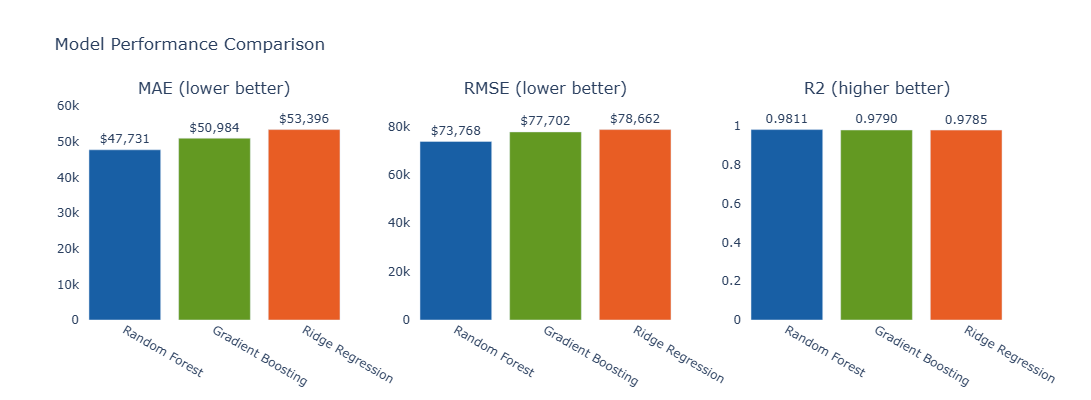

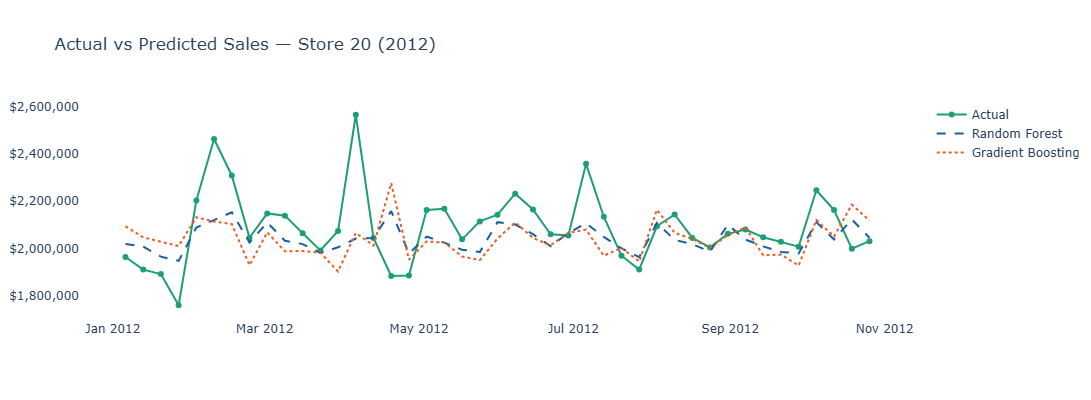

In [10]:
results_df = pd.DataFrame(results).sort_values('RMSE')

print('='*62)
print('  MODEL COMPARISON  (Test Set)')
print('='*62)

header = f'{"Model":<22} {"MAE ($)":>12} {"RMSE ($)":>12} {"MAPE %":>8} {"R2":>8}'
print(header)
print('-'*62)

for _, row in results_df.iterrows():
    print(f'{row.Model:<22} {row.MAE:>12,.0f} {row.RMSE:>12,.0f} {row["MAPE %"]:>7.2f}% {row.R2:>8.4f}')

print('='*62)

# ---------------- Performance comparison ----------------
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[
        'MAE (lower better)',
        'RMSE (lower better)',
        'R2 (higher better)'
    ]
)

colors = ['#185FA5', '#639922', '#E85D24']

for col_i, metric in enumerate(['MAE', 'RMSE', 'R2'], 1):
    fig.add_trace(
        go.Bar(
            x=results_df['Model'],
            y=results_df[metric],
            marker_color=colors,
            showlegend=False,
            text=results_df[metric].apply(
                lambda v: f'${v:,.0f}' if metric != 'R2' else f'{v:.4f}'
            ),
            textposition='outside'
        ),
        row=1,
        col=col_i
    )

fig.update_layout(
    title='Model Performance Comparison',
    height=400,
    plot_bgcolor='white'
)

fig.show()

# ---------------- Actual vs Predicted ----------------

STORE = 20

ts = test[test['Store'] == STORE].copy().reset_index(drop=True)

test_reset = test.reset_index(drop=True)
store_mask = (test_reset['Store'] == STORE)

ts['pred_rf'] = y_pred_rf[store_mask.values]
ts['pred_gb'] = y_pred_gb[store_mask.values]

fig2 = go.Figure()

fig2.add_trace(
    go.Scatter(
        x=ts['Date'],
        y=ts['Weekly_Sales'],
        mode='lines+markers',
        name='Actual',
        line=dict(color='#1D9E75', width=2)
    )
)

fig2.add_trace(
    go.Scatter(
        x=ts['Date'],
        y=ts['pred_rf'],
        mode='lines',
        name='Random Forest',
        line=dict(color='#185FA5', width=2, dash='dash')
    )
)

fig2.add_trace(
    go.Scatter(
        x=ts['Date'],
        y=ts['pred_gb'],
        mode='lines',
        name='Gradient Boosting',
        line=dict(color='#E85D24', width=2, dash='dot')
    )
)

fig2.update_layout(
    title=f'Actual vs Predicted Sales — Store {STORE} (2012)',
    height=400,
    plot_bgcolor='white',
    yaxis=dict(tickformat='$,.0f'),
    hovermode='x unified'
)

fig2.show()

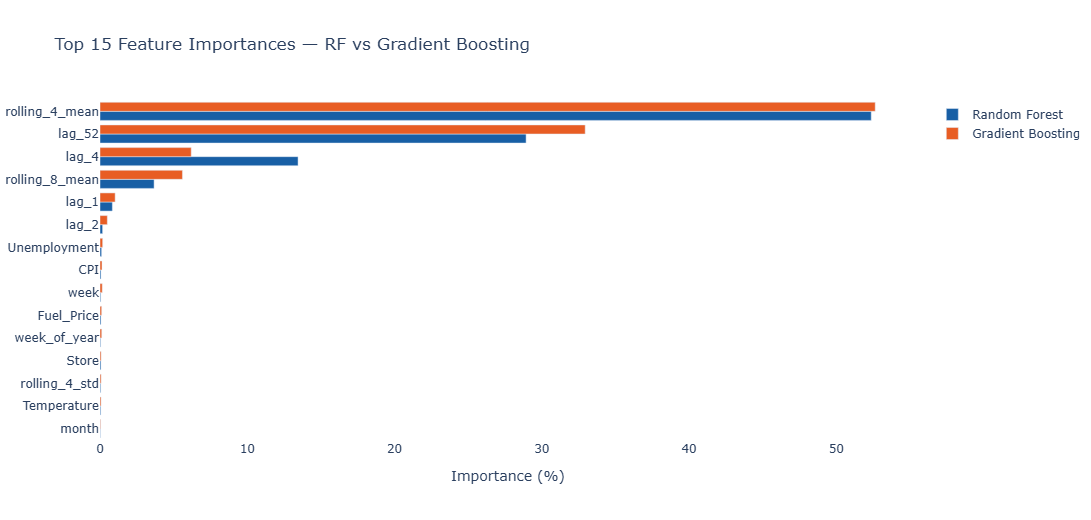

Top 5 features by importance:
rolling_4_mean          RF: 52.4%   GB: 52.6%
lag_52                  RF: 28.9%   GB: 32.9%
lag_4                   RF: 13.4%   GB: 6.2%
rolling_8_mean          RF: 3.7%   GB: 5.6%
lag_1                   RF: 0.8%   GB: 1.0%


In [11]:
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'RF_pct': rf.feature_importances_ / rf.feature_importances_.sum() * 100,
    'GB_pct': gb.feature_importances_ / gb.feature_importances_.sum() * 100
}).sort_values('RF_pct', ascending=False)

top15 = feat_imp.head(15)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=top15['RF_pct'],
    y=top15['Feature'],
    orientation='h',
    name='Random Forest',
    marker_color='#185FA5'
))

fig.add_trace(go.Bar(
    x=top15['GB_pct'],
    y=top15['Feature'],
    orientation='h',
    name='Gradient Boosting',
    marker_color='#E85D24'
))

fig.update_layout(
    barmode='group',
    title='Top 15 Feature Importances — RF vs Gradient Boosting',
    xaxis_title='Importance (%)',
    height=520,
    plot_bgcolor='white',
    yaxis=dict(categoryorder='total ascending')
)

fig.show()

print("Top 5 features by importance:")

for _, r in feat_imp.head(5).iterrows():
    print(f"{r['Feature']:<22}  RF: {r['RF_pct']:.1f}%   GB: {r['GB_pct']:.1f}%")

## 8 - week Future Sales Forecast

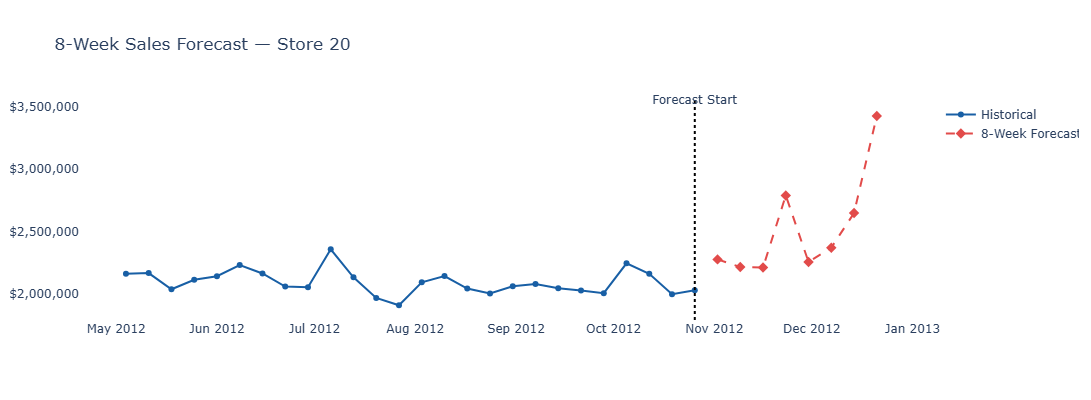


Week-by-week forecast:
2012-11-02   $2,277,461
2012-11-09   $2,216,896
2012-11-16   $2,212,668
2012-11-23   $2,788,449
2012-11-30   $2,256,855
2012-12-07   $2,371,193
2012-12-14   $2,648,002
2012-12-21   $3,422,667

Total forecasted revenue (8 weeks): $20,194,191


In [12]:
FORECAST_STORE = 20
FORECAST_WEEKS = 8

store_hist = df[df['Store'] == FORECAST_STORE].sort_values('Date').copy()

last_date = store_hist['Date'].max()
hist_sales = list(store_hist['Weekly_Sales'].values)
last_known = store_hist.iloc[-1].copy()

fc_rows = []

for w in range(1, FORECAST_WEEKS + 1):

    fd = last_date + pd.Timedelta(weeks=w)

    row = {
        'Store': FORECAST_STORE,
        'Holiday_Flag': 0,

        'Temperature': last_known['Temperature'],
        'Fuel_Price': last_known['Fuel_Price'],
        'CPI': last_known['CPI'],
        'Unemployment': last_known['Unemployment'],

        'year': fd.year,
        'month': fd.month,
        'week': int(fd.isocalendar().week),
        'week_of_year': int(fd.isocalendar().week),
        'quarter': fd.quarter,

        'is_november': int(fd.month == 11),
        'is_december': int(fd.month == 12),
        'is_q4': int(fd.month in [10, 11, 12]),
        'is_summer': int(fd.month in [6, 7, 8]),

        'pre_holiday': 0,
        'post_holiday': 0,

        'lag_1': hist_sales[-1] if len(hist_sales) >= 1 else np.nan,
        'lag_2': hist_sales[-2] if len(hist_sales) >= 2 else np.nan,
        'lag_4': hist_sales[-4] if len(hist_sales) >= 4 else np.nan,
        'lag_52': hist_sales[-52] if len(hist_sales) >= 52 else np.nan,

        'rolling_4_mean': np.mean(hist_sales[-4:]) if len(hist_sales) >= 4 else np.nan,
        'rolling_4_std': np.std(hist_sales[-4:]) if len(hist_sales) >= 4 else np.nan,
        'rolling_8_mean': np.mean(hist_sales[-8:]) if len(hist_sales) >= 8 else np.nan
    }

    # Create one-row DataFrame
    pred_df = pd.DataFrame([row])

    # Ensure the same numeric columns as training
    pred_df = pred_df.reindex(columns=X_train.columns, fill_value=0)

    pred = max(0, gb.predict(pred_df)[0])

    row['forecast_sales'] = pred
    row['Date'] = fd

    fc_rows.append(row)
    hist_sales.append(pred)

fc_df = pd.DataFrame(fc_rows)[['Date', 'forecast_sales']]

recent = store_hist.tail(26)[['Date', 'Weekly_Sales']]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=recent['Date'],
    y=recent['Weekly_Sales'],
    mode='lines+markers',
    name='Historical',
    line=dict(color='#185FA5', width=2)
))

fig.add_trace(go.Scatter(
    x=fc_df['Date'],
    y=fc_df['forecast_sales'],
    mode='lines+markers',
    name='8-Week Forecast',
    line=dict(color='#E24B4A', width=2, dash='dash'),
    marker=dict(size=8, symbol='diamond')
))

# Use add_shape instead of add_vline (avoids Timestamp compatibility issues)
fig.add_shape(
    type='line',
    x0=last_date,
    x1=last_date,
    y0=0,
    y1=1,
    xref='x',
    yref='paper',
    line=dict(color='black', dash='dot')
)

fig.add_annotation(
    x=last_date,
    y=1,
    xref='x',
    yref='paper',
    text='Forecast Start',
    showarrow=False,
    yshift=10
)

fig.update_layout(
    title=f'8-Week Sales Forecast — Store {FORECAST_STORE}',
    height=400,
    plot_bgcolor='white',
    yaxis=dict(tickformat='$,.0f'),
    hovermode='x unified'
)

fig.show()

print("\nWeek-by-week forecast:")
for _, r in fc_df.iterrows():
    print(f"{r['Date'].date()}   ${r['forecast_sales']:,.0f}")

print(f"\nTotal forecasted revenue (8 weeks): ${fc_df['forecast_sales'].sum():,.0f}")

## Final ML Summary

In [13]:
best = results_df.iloc[0]
top3 = feat_imp.head(3)['Feature'].tolist()

print('=' * 62)
print('           EDA v3 — ML FORECASTING SUMMARY')
print('=' * 62)

print(f'Best model:      {best["Model"]}')
print(f'MAE:             ${best["MAE"]:,.0f}')
print(f'RMSE:            ${best["RMSE"]:,.0f}')
print(f'MAPE:            {best["MAPE %"]:.2f}%')
print(f'R² Score:        {best["R2"]:.4f}')

print(f'\nTop 3 Sales Drivers:')
for i, feature in enumerate(top3, 1):
    print(f'  {i}. {feature}')

print(f'\n8-week forecast for Store {FORECAST_STORE}:')
print(f'  Total Forecast Sales: ${fc_df["forecast_sales"].sum():,.0f}')

print('=' * 62)

           EDA v3 — ML FORECASTING SUMMARY
Best model:      Random Forest
MAE:             $47,731
RMSE:            $73,768
MAPE:            4.69%
R² Score:        0.9811

Top 3 Sales Drivers:
  1. rolling_4_mean
  2. lag_52
  3. lag_4

8-week forecast for Store 20:
  Total Forecast Sales: $20,194,191
